# Notebook 04 — Surplus Allocation

**Purpose:** Distribute the grand coalition's net surplus $v(S)$ among all farmers
using five allocation mechanisms and compare them along stability, fairness,
and smallholder-protection dimensions.

---
**Reads:**
- `data/processed/optimization_inputs.pkl`
- `data/processed/standalone_values.pkl`
- `data/processed/characteristic_function.pkl`

**Mechanisms implemented (all using Gurobi for LP steps):**

| # | Mechanism | Core stable? | Unique? | Complexity |
|---|-----------|-------------|---------|------------|
| 1 | Core / Least Core | Maximal | Partial | Single LP |
| 2 | Nucleolus | Guaranteed (if core non-empty) | Always | Sequence of LPs |
| 3 | Shapley Value | Not guaranteed | Always | O(2^N) arithmetic |
| 4 | Equal Split | Not guaranteed | Always | O(1) |
| 5 | Proportional Split | Not guaranteed | Always | O(N) |

---
### Notation
- $S$ — grand coalition (all farmers)
- $v(S)$ — grand coalition value from Notebook 03
- $\tilde{v}(\{i\})$ — farmer $i$'s standalone value from Notebook 02
- $x_i$ — game-theoretic total entitlement for farmer $i$
- $\text{Carbon\_Transfer}_i = x_i - \text{YR}_i + \text{OC}_i$ — actual cash from manager
- $e(T, \mathbf{x}) = v(T) - \sum_{i \in T} x_i$ — excess of coalition $T$

## 0. Imports and configuration

In [1]:
import sys
import pickle
import time
import math
import warnings
from pathlib import Path
from itertools import combinations
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import gurobipy as gp
from gurobipy import GRB

sys.path.insert(0, str(Path.cwd()))
import config

print(f"Gurobi  : {gp.gurobi.version()}")
print(f"numpy   : {np.__version__}")

Gurobi  : (13, 0, 1)
numpy   : 1.26.4


## 1. Load all inputs

In [2]:
with open(config.INPUTS_PKL, "rb") as f:
    inp = pickle.load(f)

practice_names = inp["practice_names"]

with open(config.STANDALONE_PKL, "rb") as f:
    standalone_values = pickle.load(f)

with open(config.CHARACTERISTIC_FN_PKL, "rb") as f:
    cf_data = pickle.load(f)

char_fn    = cf_data["characteristic_function"]    # frozenset[str] -> float
gc_key     = cf_data["grand_coalition_key"]         # frozenset of all farmer IDs
v_gc       = cf_data["grand_coalition_value"]       # float
gc_portf   = cf_data["grand_coalition_portfolios"]  # fid -> [practice_idx]
farmer_ids = cf_data["farmer_ids"]                  # ordered list
N          = len(farmer_ids)

sv_vec = np.array([standalone_values[fid]["standalone_value"] for fid in farmer_ids])
fs_vec = np.array([standalone_values[fid]["farm_size"]        for fid in farmer_ids])

print(f"Grand coalition : {N} farmers")
print(f"v(Grand)        : {v_gc:,.0f} INR")
print(f"Sum of ṽ({{i}})  : {sv_vec.sum():,.0f} INR")
print(f"Surplus over solo sum: {v_gc - sv_vec.sum():,.0f} INR")

Grand coalition : 15 farmers
v(Grand)        : 1,499,422 INR
Sum of ṽ({i})  : 0 INR
Surplus over solo sum: 1,499,422 INR


## 2. Shared LP infrastructure

For every non-empty proper sub-coalition $T \subsetneq S$:
$$\sum_{i \in T} x_i \geq v(T)$$
which in matrix form is $A\mathbf{x} \geq \mathbf{b}$.

In [3]:
fid_to_idx = {fid: i for i, fid in enumerate(farmer_ids)}

def powerset_indices(n: int):
    """Yield all non-empty proper subsets of {0,...,n-1} as sorted tuples."""
    for r in range(1, n):
        for combo in combinations(range(n), r):
            yield combo

sub_coalitions: List[Tuple[tuple, float]] = []
for idx_tuple in powerset_indices(N):
    fid_set = frozenset(farmer_ids[i] for i in idx_tuple)
    v_T     = char_fn.get(fid_set, 0.0)
    sub_coalitions.append((idx_tuple, v_T))

M_constr = len(sub_coalitions)

A_sub = np.zeros((M_constr, N), dtype=float)
b_sub = np.zeros(M_constr,      dtype=float)
for row, (idx_tuple, v_T) in enumerate(sub_coalitions):
    for i in idx_tuple:
        A_sub[row, i] = 1.0
    b_sub[row] = v_T

print(f"Sub-coalition constraints : {M_constr:,}")
print(f"  (= 2^{N} - 2 = {2**N - 2:,} non-empty proper subsets)")

Sub-coalition constraints : 32,766
  (= 2^15 - 2 = 32,766 non-empty proper subsets)


## 3. Mechanism 1 — Core check and Least Core

**Phase 1:** check if the core is non-empty ($\varepsilon = 0$ feasibility test).

**Phase 2:** if infeasible, minimise $\varepsilon$ (least core).

In [4]:
def _make_env(silent: bool = True) -> gp.Env:
    env = gp.Env(empty=True)
    env.setParam("OutputFlag", 0 if silent else 1)
    env.setParam("TimeLimit",  config.GUROBI_TIME_LIMIT)
    env.start()
    return env


def check_core_and_least_core(
    v_grand: float,
    sv: np.ndarray,
    A: np.ndarray,
    b: np.ndarray,
    n: int,
) -> Dict:
    """
    Phase 1: feasibility check at ε = 0.
    Phase 2: if infeasible, minimise ε (least core).

    Returns dict: core_nonempty, epsilon_star, allocation, stable.
    """
    # Phase 1 — core check
    env   = _make_env()
    model = gp.Model("core_check", env=env)
    x     = model.addVars(n, lb=-GRB.INFINITY, name="x")
    model.addConstr(gp.quicksum(x[i] for i in range(n)) == v_grand, "efficiency")
    for i in range(n):
        model.addConstr(x[i] >= sv[i], f"IR_{i}")
    for row in range(len(b)):
        lhs = gp.quicksum(A[row, i] * x[i] for i in range(n) if A[row, i] != 0)
        model.addConstr(lhs >= b[row], f"core_{row}")
    model.setObjective(0, GRB.MINIMIZE)
    model.optimize()

    if model.Status == GRB.OPTIMAL:
        alloc = np.array([x[i].X for i in range(n)])
        model.dispose(); env.dispose()
        return {"core_nonempty": True, "epsilon_star": 0.0,
                "allocation": alloc, "stable": True}

    model.dispose(); env.dispose()

    # Phase 2 — least core
    env   = _make_env()
    model = gp.Model("least_core", env=env)
    x     = model.addVars(n, lb=-GRB.INFINITY, name="x")
    eps   = model.addVar(lb=0.0, name="epsilon")
    model.addConstr(gp.quicksum(x[i] for i in range(n)) == v_grand, "efficiency")
    for i in range(n):
        model.addConstr(x[i] >= sv[i], f"IR_{i}")
    for row in range(len(b)):
        lhs = gp.quicksum(A[row, i] * x[i] for i in range(n) if A[row, i] != 0)
        model.addConstr(lhs >= b[row] - eps, f"lc_{row}")
    model.setObjective(eps, GRB.MINIMIZE)
    model.optimize()

    if model.Status == GRB.OPTIMAL:
        alloc  = np.array([x[i].X for i in range(n)])
        e_star = eps.X
        model.dispose(); env.dispose()
        return {"core_nonempty": False, "epsilon_star": e_star,
                "allocation": alloc, "stable": e_star <= config.EPSILON_MAX}

    status_code = model.Status
    model.dispose(); env.dispose()
    raise RuntimeError(f"Least core LP failed with status {status_code}")


print("Running core check / least core...")
t0 = time.perf_counter()
lc_result = check_core_and_least_core(v_gc, sv_vec, A_sub, b_sub, N)
print(f"Done in {time.perf_counter()-t0:.2f} s")
print(f"Core non-empty : {lc_result['core_nonempty']}")
print(f"ε*             : {lc_result['epsilon_star']:,.4f} INR")
print(f"Stable         : {lc_result['stable']}  (ε_max = {config.EPSILON_MAX})")

Running core check / least core...
Done in 2.76 s
Core non-empty : True
ε*             : 0.0000 INR
Stable         : True  (ε_max = 0.0001)


## 4. Mechanism 2 — Nucleolus

Lexicographically minimises the sorted vector of sub-coalition excesses
$e(T, \mathbf{x}) = v(T) - \sum_{i \in T} x_i$ via iterated least-core LPs.

In [5]:
def compute_nucleolus(
    v_grand: float,
    sv: np.ndarray,
    A: np.ndarray,
    b: np.ndarray,
    n: int,
    tol: float = 1e-6,
    max_iter: int = 200,
    verbose: bool = False,
) -> Dict:
    """
    Nucleolus via Maschler-Peleg-Shapley sequential reduction.

    Returns dict: allocation, n_iterations, epsilon_sequence.
    """
    M          = len(b)
    active     = np.ones(M, dtype=bool)
    pinned_eps = np.full(M, np.nan)
    eps_sequence = []
    x_solution   = None

    for iteration in range(max_iter):
        n_active = active.sum()
        if n_active == 0:
            break

        env   = _make_env()
        model = gp.Model(f"nucleolus_iter_{iteration}", env=env)
        x     = model.addVars(n, lb=-GRB.INFINITY, name="x")
        eps   = model.addVar(lb=-GRB.INFINITY, name="eps")

        model.addConstr(gp.quicksum(x[i] for i in range(n)) == v_grand, "efficiency")
        for i in range(n):
            model.addConstr(x[i] >= sv[i], f"IR_{i}")

        # Pinned constraints → equalities
        for row in range(M):
            if not active[row] and not np.isnan(pinned_eps[row]):
                lhs = gp.quicksum(A[row, i] * x[i] for i in range(n) if A[row, i] != 0)
                model.addConstr(lhs == b[row] - pinned_eps[row], f"pinned_{row}")

        # Active constraints → excess ≤ ε
        for row in range(M):
            if active[row]:
                lhs = gp.quicksum(A[row, i] * x[i] for i in range(n) if A[row, i] != 0)
                model.addConstr(lhs >= b[row] - eps, f"active_{row}")

        model.setObjective(eps, GRB.MINIMIZE)
        model.optimize()

        if model.Status != GRB.OPTIMAL:
            status_code = model.Status
            model.dispose(); env.dispose()
            warnings.warn(
                f"Nucleolus iteration {iteration} returned status {status_code}. "
                "Returning best available allocation."
            )
            break

        x_vals  = np.array([x[i].X for i in range(n)])
        eps_val = eps.X
        eps_sequence.append(eps_val)

        if verbose:
            print(f"  Iter {iteration:3d}: ε* = {eps_val:+.4f}  active = {n_active}")

        new_pinned = 0
        for row in range(M):
            if active[row]:
                excess = b[row] - float(A[row] @ x_vals)
                if abs(excess - eps_val) <= tol:
                    active[row]     = False
                    pinned_eps[row] = eps_val
                    new_pinned     += 1

        x_solution = x_vals
        model.dispose(); env.dispose()

        if verbose:
            print(f"           pinned {new_pinned} constraints")

        if active.sum() == 0:
            break

    return {"allocation": x_solution, "n_iterations": len(eps_sequence),
            "epsilon_sequence": eps_sequence}


print("Running nucleolus (sequence of LPs)...")
t0 = time.perf_counter()
nuc_result = compute_nucleolus(v_gc, sv_vec, A_sub, b_sub, N, tol=1e-6, max_iter=200, verbose=True)
print(f"\nDone in {time.perf_counter()-t0:.2f} s")
print(f"Iterations   : {nuc_result['n_iterations']}")
print(f"ε sequence   : {[f'{e:.4f}' for e in nuc_result['epsilon_sequence']]}")

Running nucleolus (sequence of LPs)...
  Iter   0: ε* = -703.0627  active = 32766
           pinned 15 constraints
  Iter   1: ε* = -1355.2537  active = 32751
           pinned 1 constraints
  Iter   2: ε* = -1358.4634  active = 32750
           pinned 1 constraints
  Iter   3: ε* = -1363.3877  active = 32749
           pinned 1 constraints
  Iter   4: ε* = -1364.7797  active = 32748
           pinned 1 constraints
  Iter   5: ε* = -1367.3614  active = 32747
           pinned 1 constraints
  Iter   6: ε* = -1371.3618  active = 32746
           pinned 1 constraints
  Iter   7: ε* = -1372.4928  active = 32745
           pinned 1 constraints
  Iter   8: ε* = -1373.5504  active = 32744
           pinned 1 constraints
  Iter   9: ε* = -1374.6099  active = 32743
           pinned 1 constraints
  Iter  10: ε* = -1375.3485  active = 32742
           pinned 1 constraints
  Iter  11: ε* = -1377.8593  active = 32741
           pinned 1 constraints
  Iter  12: ε* = -1378.3464  active = 32740
     

/var/folders/2v/pnt0bgkj0rz4f85np7_clwxm0000gn/T/ipykernel_89215/2340745022.py:54: UserWarning: Nucleolus iteration 101 returned status 3. Returning best available allocation.
  warnings.warn(


## 5. Mechanism 3 — Shapley Value

$$\phi_i = \sum_{T \subseteq S \setminus \{i\}}
\frac{|T|!\;(|S|-|T|-1)!}{|S|!}\;\bigl[v(T\cup\{i\}) - v(T)\bigr]$$

Computed purely from the characteristic function table — no new Gurobi solves.

In [6]:
def compute_shapley(farmer_ids: List[str], char_fn: Dict) -> np.ndarray:
    """Exact Shapley value from the characteristic function table."""
    n           = len(farmer_ids)
    factorial_n = math.factorial(n)
    shapley     = np.zeros(n)

    for idx_i, fid_i in enumerate(farmer_ids):
        others       = [fid for fid in farmer_ids if fid != fid_i]
        contribution = 0.0
        for r in range(len(others) + 1):
            weight = math.factorial(r) * math.factorial(n - r - 1) / factorial_n
            for T_tuple in combinations(others, r):
                T_set      = frozenset(T_tuple)
                T_plus_i   = T_set | frozenset([fid_i])
                v_T        = char_fn.get(T_set,    0.0)
                v_T_plus_i = char_fn.get(T_plus_i, 0.0)
                contribution += weight * (v_T_plus_i - v_T)
        shapley[idx_i] = contribution

    return shapley


print("Computing Shapley values...")
t0 = time.perf_counter()
shapley_alloc = compute_shapley(farmer_ids, char_fn)
print(f"Done in {time.perf_counter()-t0:.2f} s")
shapley_sum = shapley_alloc.sum()
print(f"Σ φ_i = {shapley_sum:,.2f}  v(Grand) = {v_gc:,.2f}  diff = {abs(shapley_sum-v_gc):.4f}")
assert abs(shapley_sum - v_gc) < 1.0, "Shapley efficiency violated!"
print("Efficiency check: PASS ✓")

Computing Shapley values...
Done in 0.23 s
Σ φ_i = 1,499,421.69  v(Grand) = 1,499,421.69  diff = 0.0000
Efficiency check: PASS ✓


## 6. Mechanisms 4 & 5 — Equal Split and Proportional Split

**Note:** `seq_gc` (sequestration per farmer in grand coalition) is computed
with pairwise interaction terms in Section 6b below and overrides the
placeholder here.  The proportional split cell re-runs after 6b.

In [20]:
equal_alloc = np.full(N, v_gc / N)
print(f"Equal split per farmer : {v_gc/N:,.0f} INR")
# seq_gc and prop_alloc are finalised in cell 6b / 6d below.

Equal split per farmer : 99,961 INR


## 6b. Grand-coalition per-farmer actuals

Compute each farmer's **yield revenue** (YR) and **operational cost** (OC)
under their grand-coalition portfolio, *including pairwise interaction terms*.

These quantities serve two purposes:

1. **Carbon transfer** — the actual cash the coalition manager pays farmer $i$:
   $$\text{Carbon\_Transfer}_i = x_i - \text{YR}_i + \text{OC}_i$$
   $x_i$ already embeds YR and OC inside every $v(T)$ that built the LP,
   so subtracting $\text{YR}_i$ removes money the farmer already collected
   from the crop market, and adding $\text{OC}_i$ reimburses costs they paid.

2. **Corrected proportional split weight** —
   $\text{FS}_i \times \text{CSP}_i(\Pi_i^{\text{co}})$ including $\alpha_{jk}$ terms.

In [21]:
Alpha_mat = inp["Alpha"]
Beta_mat  = inp["Beta"]
Gamma_mat = inp["Gamma"]

practices_df_nb04  = inp["practices"]
M_prac             = len(practice_names)

CSP_base_nb04 = (practices_df_nb04.set_index("Practice")
                 .reindex(practice_names)["Net_CSP_base"].values)
OC_base_nb04  = (practices_df_nb04.set_index("Practice")
                 .reindex(practice_names)["Net_OC_per_ha"].values)
YLD_base_nb04 = (practices_df_nb04.set_index("Practice")
                 .reindex(practice_names)["Base_yield_change"].values)

PADDY   = config.PADDY_PRICE
CCP_val = config.CCP


def compute_farmer_actuals(portfolio_idx: list, farm_size: float) -> dict:
    """
    YR_i, OC_i, CSP_i for a farmer and portfolio, with pairwise interactions.

    Returns dict: yr_inr, oc_inr, csp_tco2, carbon_rev_inr
    """
    adopted = portfolio_idx
    if not adopted:
        return {"yr_inr": 0.0, "oc_inr": 0.0, "csp_tco2": 0.0, "carbon_rev_inr": 0.0}

    FS = farm_size

    csp_lin = sum(CSP_base_nb04[j] for j in adopted)
    oc_lin  = sum(OC_base_nb04[j]  for j in adopted)
    yld_lin = sum(YLD_base_nb04[j] for j in adopted)

    csp_int = oc_int = yld_int = 0.0
    for a_idx, j in enumerate(adopted):
        for k in adopted[a_idx + 1:]:
            csp_int += Alpha_mat[j, k]
            oc_int  += Beta_mat[j, k]
            yld_int += Gamma_mat[j, k]

    csp_total = FS * (csp_lin + csp_int)
    oc_total  = FS * (oc_lin  + oc_int)
    yr_total  = FS * PADDY * (yld_lin + yld_int)

    return {"csp_tco2": csp_total, "oc_inr": oc_total,
            "yr_inr": yr_total, "carbon_rev_inr": csp_total * CCP_val}


gc_actuals = {
    fid: compute_farmer_actuals(gc_portf.get(fid, []), standalone_values[fid]["farm_size"])
    for fid in farmer_ids
}

yr_gc_vec = np.array([gc_actuals[fid]["yr_inr"]         for fid in farmer_ids])
oc_gc_vec = np.array([gc_actuals[fid]["oc_inr"]         for fid in farmer_ids])
cr_gc_vec = np.array([gc_actuals[fid]["carbon_rev_inr"] for fid in farmer_ids])
seq_gc    = np.array([gc_actuals[fid]["csp_tco2"]       for fid in farmer_ids])

# Certification cost for grand coalition
total_ha_gc = fs_vec.sum()
cert_gc = (config.FIXED_MRV
           + config.VARIABLE_MRV * (total_ha_gc ** config.DELTA_MRV)
           + config.FIXED_T
           + config.VARIABLE_T * N)

carbon_pool = cr_gc_vec.sum() - cert_gc
recon_vgc   = cr_gc_vec.sum() + yr_gc_vec.sum() - oc_gc_vec.sum() - cert_gc

print("Grand coalition reconciliation")
print(f"  Σ Carbon rev    : {cr_gc_vec.sum():>15,.0f} INR")
print(f"  Σ Yield rev     : {yr_gc_vec.sum():>15,.0f} INR")
print(f"  Σ OC            : {oc_gc_vec.sum():>15,.0f} INR")
print(f"  Cert costs      : {cert_gc:>15,.0f} INR")
print(f"  Recon v(Grand)  : {recon_vgc:>15,.0f} INR")
print(f"  Stored v(Grand) : {v_gc:>15,.0f} INR")
diff_recon = abs(recon_vgc - v_gc)
print(f"  Diff            : {diff_recon:>15.2f} INR  "
      f"({'OK ✓' if diff_recon < 10 else 'MISMATCH — check grand-coalition portfolios'})")
print()
print(f"  Carbon pool (manager holds) : {carbon_pool:>15,.0f} INR")
print(f"  = Σ Carbon rev − cert costs")

Grand coalition reconciliation
  Σ Carbon rev    :         299,304 INR
  Σ Yield rev     :       1,064,307 INR
  Σ OC            :        -162,523 INR
  Cert costs      :          26,713 INR
  Recon v(Grand)  :       1,499,422 INR
  Stored v(Grand) :       1,499,422 INR
  Diff            :            0.00 INR  (OK ✓)

  Carbon pool (manager holds) :         272,591 INR
  = Σ Carbon rev − cert costs


## 6c. Carbon transfer helper

$$\text{Carbon\_Transfer}_i = x_i - \text{YR}_i + \text{OC}_i$$

**Conservation check:** $\sum_i \text{CT}_i = \text{Carbon\_pool}$, because
$\sum_i x_i = v(S) = \text{Carbon\_pool} + \sum_i(\text{YR}_i - \text{OC}_i)$.

In [22]:
def carbon_transfers(alloc: np.ndarray) -> np.ndarray:
    """Actual cash the manager pays each farmer given game-theoretic allocation x."""
    return alloc - yr_gc_vec + oc_gc_vec


def verify_carbon_pool(transfers: np.ndarray, name: str, tol: float = 5.0):
    diff   = abs(transfers.sum() - carbon_pool)
    status = "OK ✓" if diff <= tol else f"FAIL (diff={diff:.2f})"
    print(f"  {name:<15}: Σ transfers = {transfers.sum():>12,.0f}  "
          f"carbon_pool = {carbon_pool:>12,.0f}  {status}")

## 6d. Proportional split (uses corrected seq_gc from 6b)

In [23]:
seq_total = seq_gc.sum()
if seq_total > 0:
    prop_alloc = (seq_gc / seq_total) * v_gc
else:
    prop_alloc = equal_alloc.copy()
    warnings.warn("Total sequestration is zero — proportional split falls back to equal split.")

print(f"Total seq. (grand coal) : {seq_total:.3f} tCO2/season")
print(f"Proportional split range: [{prop_alloc.min():,.0f}, {prop_alloc.max():,.0f}] INR")

Total seq. (grand coal) : 199.536 tCO2/season
Proportional split range: [23,746, 211,457] INR


## 7. Post-hoc stability verification for all mechanisms

In [24]:
def verify_allocation(
    alloc: np.ndarray,
    name: str,
    v_grand: float,
    sv: np.ndarray,
    A: np.ndarray,
    b: np.ndarray,
    n: int,
    tol: float = 1.0,
) -> Dict:
    """Check efficiency, IR, and core constraints."""
    results = {"mechanism": name}

    eff_diff = abs(alloc.sum() - v_grand)
    results["efficiency_ok"]   = eff_diff <= tol
    results["efficiency_diff"] = eff_diff

    ir_violations = [i for i in range(n) if alloc[i] < sv[i] - tol]
    results["IR_ok"]         = len(ir_violations) == 0
    results["IR_violations"] = ir_violations

    core_violations = []
    max_excess      = -np.inf
    for row in range(len(b)):
        alloc_sum  = float(A[row] @ alloc)
        excess     = b[row] - alloc_sum
        max_excess = max(max_excess, excess)
        if excess > tol:
            core_violations.append(row)

    results["core_ok"]           = len(core_violations) == 0
    results["n_core_violations"] = len(core_violations)
    results["max_excess"]        = max_excess
    return results


mechanisms = {
    "Least Core"   : lc_result["allocation"],
    "Nucleolus"    : nuc_result["allocation"],
    "Shapley"      : shapley_alloc,
    "Equal Split"  : equal_alloc,
    "Proportional" : prop_alloc,
}

verification_results = {}
for name, alloc in mechanisms.items():
    if alloc is None:
        print(f"  {name:<15}: allocation is None — skipped")
        continue
    verification_results[name] = verify_allocation(
        alloc, name, v_gc, sv_vec, A_sub, b_sub, N
    )

print(f"{'Mechanism':<15}  {'Efficient':>9}  {'IR OK':>7}  "
      f"{'Core OK':>8}  {'#Violations':>12}  {'Max Excess':>12}")
print("-" * 75)
for name, vr in verification_results.items():
    print(f"{name:<15}  "
          f"{'YES' if vr['efficiency_ok'] else 'NO':>9}  "
          f"{'YES' if vr['IR_ok'] else 'NO':>7}  "
          f"{'YES' if vr['core_ok'] else 'NO':>8}  "
          f"{vr['n_core_violations']:>12,}  "
          f"{vr['max_excess']:>12.2f}")

print()
for name, vr in verification_results.items():
    if not vr["IR_ok"]:
        fids = [farmer_ids[i] for i in vr["IR_violations"]]
        print(f"  IR violations in {name}: {fids}")

print()
print("Carbon pool verification (Σ carbon transfers must equal carbon pool):")
for name, alloc in mechanisms.items():
    if alloc is not None:
        verify_carbon_pool(carbon_transfers(alloc), name)

Mechanism        Efficient    IR OK   Core OK   #Violations    Max Excess
---------------------------------------------------------------------------
Least Core             YES      YES       YES             0          0.00
Nucleolus              YES      YES       YES             0       -703.06
Shapley                YES      YES        NO         9,734      50498.85
Equal Split            YES      YES        NO        15,237     354039.63
Proportional           YES      YES        NO            21        504.01


Carbon pool verification (Σ carbon transfers must equal carbon pool):
  Least Core     : Σ transfers =      272,591  carbon_pool =      272,591  OK ✓
  Nucleolus      : Σ transfers =      272,591  carbon_pool =      272,591  OK ✓
  Shapley        : Σ transfers =      272,591  carbon_pool =      272,591  OK ✓
  Equal Split    : Σ transfers =      272,591  carbon_pool =      272,591  OK ✓
  Proportional   : Σ transfers =      272,591  carbon_pool =      272,591  OK ✓


## 8. Main comparison table

Two values are shown per mechanism per farmer:

| Column suffix | Meaning |
|---------------|---------|
| `_x`        | Total game-theoretic entitlement $x_i$ — used for IR and core checks |
| `_transfer` | Actual carbon cash from manager: $x_i - \text{YR}_i + \text{OC}_i$ |

The transfer is what field implementation uses.
The entitlement is what the cooperative-game algorithms produce.

In [25]:
rows = []
for i, fid in enumerate(farmer_ids):
    yr_i = yr_gc_vec[i]
    oc_i = oc_gc_vec[i]
    row = {
        "Farmer"       : fid,
        "Farm_ha"      : round(fs_vec[i], 2),
        "Standalone_x" : round(sv_vec[i], 0),
        "YR_grand_INR" : round(yr_i, 0),
        "OC_grand_INR" : round(oc_i, 0),
    }
    for mech_name, col_x, col_ct in [
        ("Least Core",   "LC_x",   "LC_transfer"),
        ("Nucleolus",    "Nuc_x",  "Nuc_transfer"),
        ("Shapley",      "Shap_x", "Shap_transfer"),
        ("Equal Split",  "ES_x",   "ES_transfer"),
        ("Proportional", "PS_x",   "PS_transfer"),
    ]:
        alloc = mechanisms[mech_name]
        if alloc is None:
            row[col_x] = row[col_ct] = None
        else:
            xi     = alloc[i]
            ct     = xi - yr_i + oc_i
            ir_bad = set(verification_results.get(mech_name, {}).get("IR_violations", []))
            row[col_x]  = f"{xi:,.0f}" + (" *" if i in ir_bad else "")
            row[col_ct] = round(ct, 0)
    rows.append(row)

df_alloc = pd.DataFrame(rows)
pd.set_option("display.max_columns", None)
pd.set_option("display.width",       240)
pd.set_option("display.float_format", lambda x: f"{x:,.0f}")
display(df_alloc)

print()
print("* = individual rationality violated on total entitlement x_i")
print()

# Column totals
print(f"{'':30s}  {'Σ Total Entitlement':>22}  {'Σ Carbon Transfer':>22}")
print("-" * 80)
for mech_name, col_x, col_ct in [
    ("Least Core",   "LC_x",   "LC_transfer"),
    ("Nucleolus",    "Nuc_x",  "Nuc_transfer"),
    ("Shapley",      "Shap_x", "Shap_transfer"),
    ("Equal Split",  "ES_x",   "ES_transfer"),
    ("Proportional", "PS_x",   "PS_transfer"),
]:
    alloc = mechanisms[mech_name]
    if alloc is None:
        continue
    total_x  = alloc.sum()
    total_ct = carbon_transfers(alloc).sum()
    print(f"  {mech_name:<28}  {total_x:>22,.0f}  {total_ct:>22,.0f}")

print()
print(f"  v(Grand)    = {v_gc:,.0f} INR   ← all Σ entitlements should equal this")
print(f"  Carbon pool = {carbon_pool:,.0f} INR   ← all Σ transfers should equal this")

,Farmer,Farm_ha,Standalone_x,YR_grand_INR,OC_grand_INR,LC_x,LC_transfer,Nuc_x,Nuc_transfer,Shap_x,Shap_transfer,ES_x,ES_transfer,PS_x,PS_transfer
0,F0001,1,0,"65,817","-10,050","93,194","17,326","92,640","16,772","94,135","18,268","99,961","24,094","92,724","16,857"
1,F0002,0,0,"16,856","-2,574","23,482","4,053","22,831","3,401","15,391","-4,038","99,961","80,532","23,746","4,317"
2,F0003,1,0,"102,739","-15,689","145,809","27,382","145,278","26,851","157,264","38,837","99,961","-18,466","144,741","26,313"
3,F0004,2,0,"124,410","-18,998","176,783","33,375","176,173","32,766","180,141","36,733","99,961","-43,446","175,272","31,864"
4,F0005,1,0,"55,383","-8,457","78,373","14,533","77,763","13,923","74,668","10,828","99,961","36,122","78,024","14,185"
5,F0006,0,0,"35,316","-5,393","49,761","9,052","49,153","8,443","40,844",135,"99,961","59,252","49,755","9,045"
6,F0007,1,0,"48,159","-7,354","68,076","12,563","67,463","11,951","62,414","6,902","99,961","44,449","67,847","12,334"
7,F0008,0,0,"20,869","-3,187","29,207","5,152","28,553","4,498","20,568","-3,488","99,961","75,906","29,400","5,345"
8,F0009,1,0,"117,186","-17,895","166,358","31,277","165,875","30,794","169,873","34,792","99,961","-35,119","165,095","30,014"
9,F0010,1,0,"105,949","-16,179","150,559","28,431","149,856","27,728","153,417","31,289","99,961","-22,166","149,264","27,136"



* = individual rationality violated on total entitlement x_i

                                   Σ Total Entitlement       Σ Carbon Transfer
--------------------------------------------------------------------------------
  Least Core                                 1,499,422                 272,591
  Nucleolus                                  1,499,422                 272,591
  Shapley                                    1,499,422                 272,591
  Equal Split                                1,499,422                 272,591
  Proportional                               1,499,422                 272,591

  v(Grand)    = 1,499,422 INR   ← all Σ entitlements should equal this
  Carbon pool = 272,591 INR   ← all Σ transfers should equal this


## 9. Excess analysis — who wants to defect and under which mechanism?

In [26]:
def top_excess_coalitions(
    alloc: np.ndarray,
    A: np.ndarray,
    b: np.ndarray,
    sub_coalitions: list,
    farmer_ids: list,
    top_k: int = 5,
) -> pd.DataFrame:
    excesses = []
    for row, (idx_tuple, v_T) in enumerate(sub_coalitions):
        alloc_sum = float(A[row] @ alloc)
        excess    = v_T - alloc_sum
        excesses.append({
            "coalition" : ", ".join(farmer_ids[i] for i in idx_tuple),
            "size"      : len(idx_tuple),
            "v_T"       : round(v_T, 0),
            "alloc_sum" : round(alloc_sum, 0),
            "excess"    : round(excess, 2),
        })
    return (pd.DataFrame(excesses)
            .sort_values("excess", ascending=False)
            .head(top_k)
            .reset_index(drop=True))


for name in ["Least Core", "Nucleolus", "Shapley"]:
    alloc = mechanisms[name]
    if alloc is None:
        continue
    df_ex = top_excess_coalitions(alloc, A_sub, b_sub, sub_coalitions, farmer_ids)
    print(f"\n{'='*60}")
    print(f"Top-5 highest-excess sub-coalitions under {name}")
    print(f"{'='*60}")
    display(df_ex)


Top-5 highest-excess sub-coalitions under Least Core


,coalition,size,v_T,alloc_sum,excess
0,"F0001, F0007, F0008, F0011, F0012",5,"468,430","468,430",0
1,"F0001, F0002, F0003, F0004, F0005, F0006, F000...",13,"1,248,673","1,248,673",0
2,"F0001, F0002, F0003, F0004, F0005, F0006, F000...",12,"1,138,202","1,138,202",0
3,"F0001, F0009, F0012",3,"463,721","463,721",0
4,"F0001, F0002, F0006, F0007, F0011, F0012",6,"512,466","512,466",-0



Top-5 highest-excess sub-coalitions under Nucleolus


,coalition,size,v_T,alloc_sum,excess
0,"F0002, F0003, F0004, F0005, F0006, F0007, F000...",14,"1,406,079","1,406,782",-703
1,"F0001, F0002, F0003, F0004, F0005, F0006, F000...",14,"1,470,166","1,470,869",-703
2,"F0001, F0002, F0003, F0004, F0005, F0006, F000...",14,"1,399,213","1,399,916",-703
3,"F0001, F0002, F0003, F0004, F0005, F0006, F000...",14,"1,470,166","1,470,869",-703
4,"F0001, F0002, F0003, F0004, F0005, F0006, F000...",14,"1,388,914","1,389,617",-703



Top-5 highest-excess sub-coalitions under Shapley


,coalition,size,v_T,alloc_sum,excess
0,"F0001, F0002, F0005, F0006, F0007, F0008, F001...",10,"646,409","595,910","50,499"
1,"F0002, F0005, F0006, F0007, F0008, F0010, F001...",10,"703,547","655,191","48,355"
2,"F0002, F0004, F0005, F0006, F0007, F0008, F001...",10,"729,834","681,915","47,918"
3,"F0002, F0005, F0006, F0007, F0008, F0009, F001...",10,"719,547","671,647","47,900"
4,"F0001, F0002, F0005, F0006, F0007, F0008, F001...",11,"796,774","749,327","47,447"


## 10. Visualisations

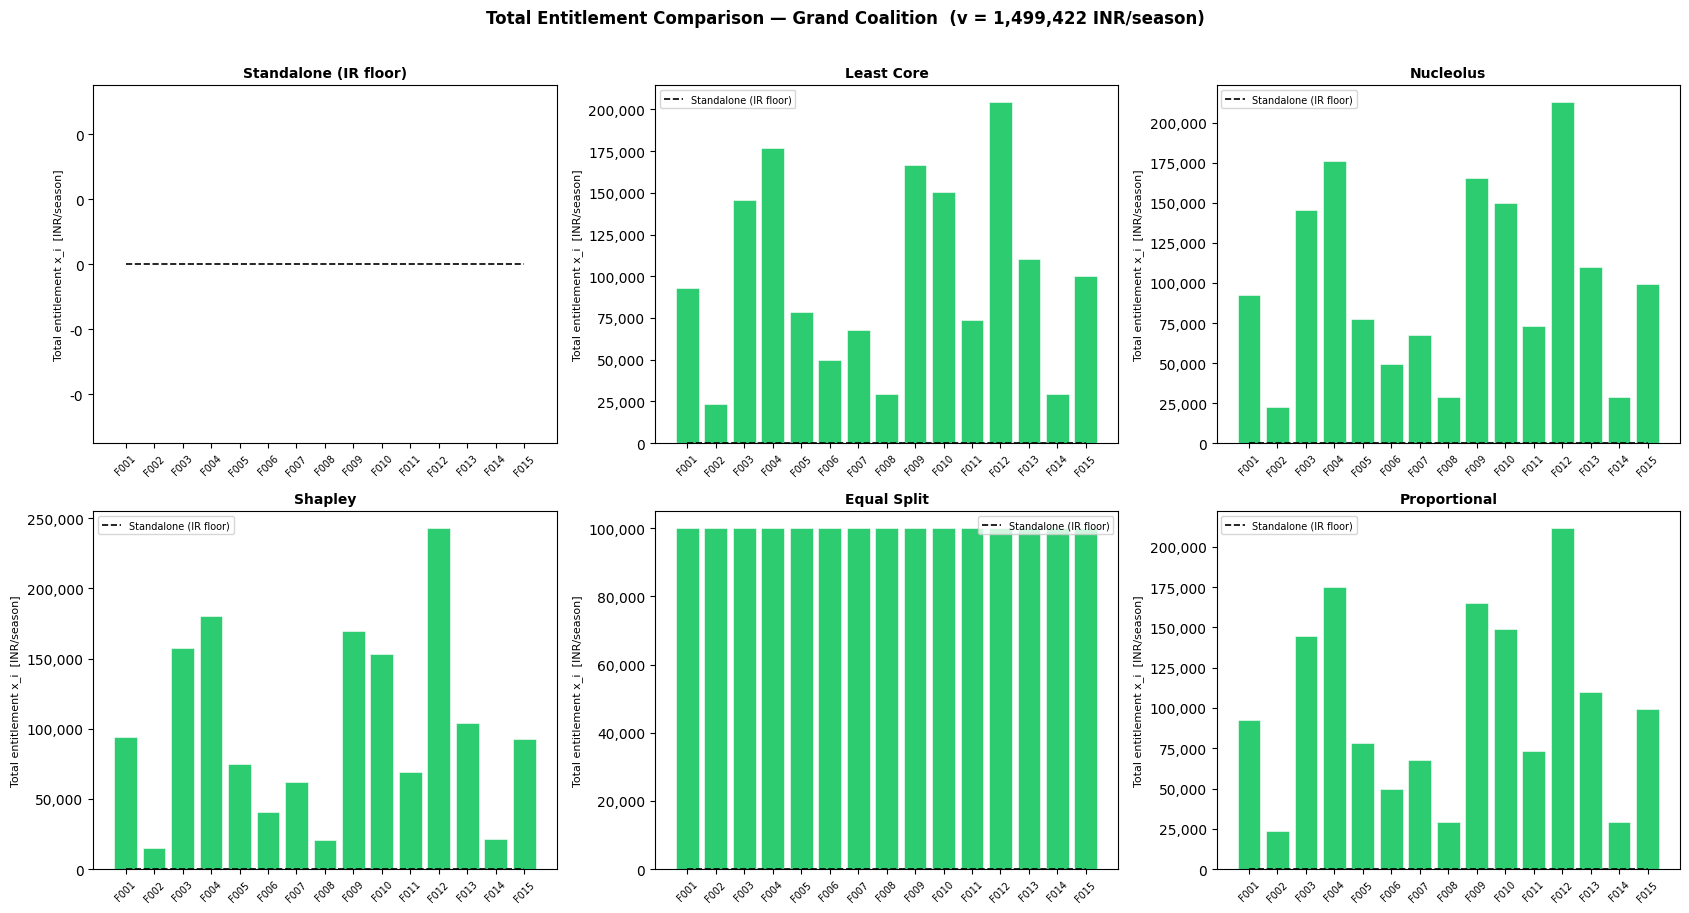

Figure 1 saved.


In [27]:
# Plot 1: Total entitlement comparison across mechanisms
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
axes = axes.flatten()

plot_order = [
    ("Standalone (IR floor)", sv_vec),
    ("Least Core",            lc_result["allocation"]),
    ("Nucleolus",             nuc_result["allocation"]),
    ("Shapley",               shapley_alloc),
    ("Equal Split",           equal_alloc),
    ("Proportional",          prop_alloc),
]
x_ticks    = range(N)
fid_labels = [fid.replace("F0", "F") for fid in farmer_ids]

for ax, (title, alloc) in zip(axes, plot_order):
    if alloc is None:
        ax.set_title(f"{title}\n(unavailable)", fontsize=9)
        ax.axis("off")
        continue
    colors = ["#2ecc71" if alloc[i] >= sv_vec[i] else "#e74c3c" for i in range(N)]
    ax.bar(x_ticks, alloc, color=colors, edgecolor="white", linewidth=0.4)
    ax.step(x_ticks, sv_vec, where="mid", color="black",
            linewidth=1.2, linestyle="--", label="Standalone (IR floor)")
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(fid_labels, rotation=45, fontsize=7)
    ax.set_ylabel("Total entitlement x_i  [INR/season]", fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    if title != "Standalone (IR floor)":
        ax.legend(fontsize=7)

fig.suptitle(
    f"Total Entitlement Comparison — Grand Coalition  (v = {v_gc:,.0f} INR/season)",
    fontsize=12, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig(f"{config.PROCESSED_DIR}/nb04_entitlement_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure 1 saved.")

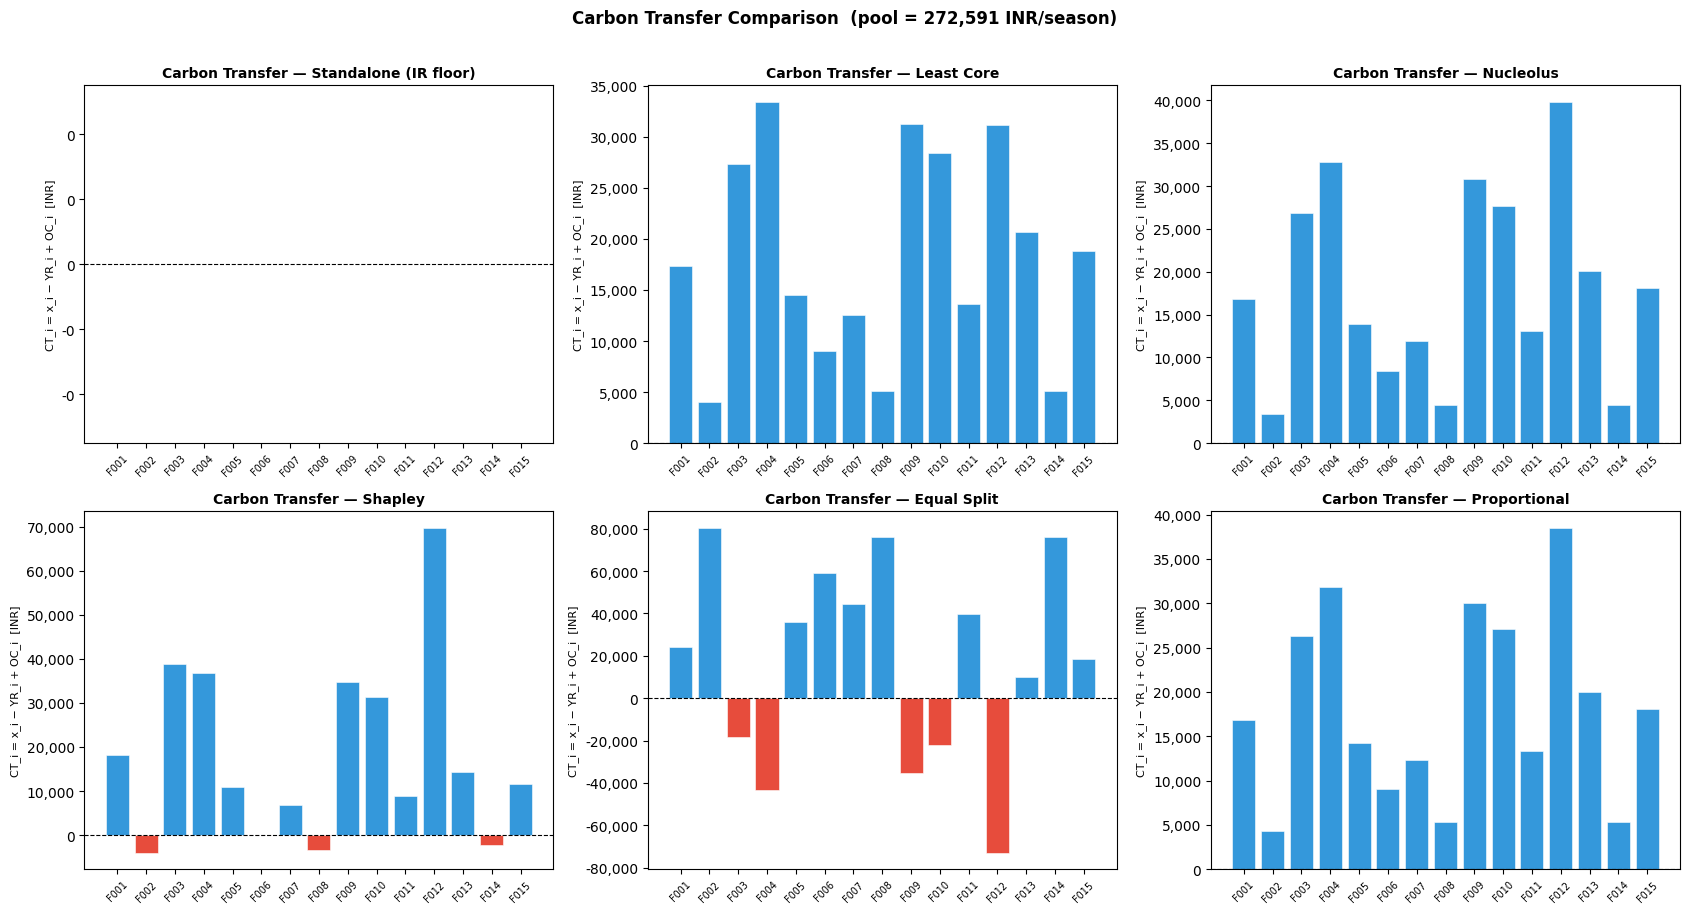

Figure 2 saved.


In [28]:
# Plot 2: Carbon transfer comparison (what the manager actually pays)
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
axes = axes.flatten()

ct_plot_order = [
    ("Standalone (IR floor)", sv_vec),   # for reference
    ("Least Core",   carbon_transfers(lc_result["allocation"])),
    ("Nucleolus",    carbon_transfers(nuc_result["allocation"])),
    ("Shapley",      carbon_transfers(shapley_alloc)),
    ("Equal Split",  carbon_transfers(equal_alloc)),
    ("Proportional", carbon_transfers(prop_alloc)),
]

for ax, (title, ct) in zip(axes, ct_plot_order):
    if ct is None:
        ax.axis("off")
        continue
    colors = ["#3498db" if ct[i] >= 0 else "#e74c3c" for i in range(N)]
    ax.bar(x_ticks, ct, color=colors, edgecolor="white", linewidth=0.4)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(f"Carbon Transfer — {title}", fontsize=10, fontweight="bold")
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(fid_labels, rotation=45, fontsize=7)
    ax.set_ylabel("CT_i = x_i − YR_i + OC_i  [INR]", fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

fig.suptitle(
    f"Carbon Transfer Comparison  (pool = {carbon_pool:,.0f} INR/season)",
    fontsize=12, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig(f"{config.PROCESSED_DIR}/nb04_carbon_transfer_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure 2 saved.")

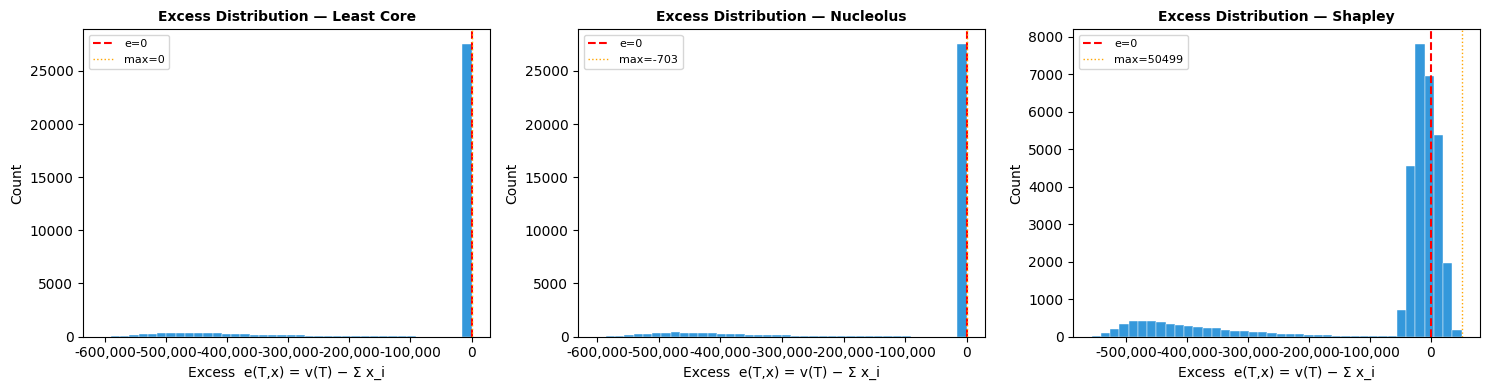

Figure 3 saved.


In [29]:
# Plot 3: Excess distributions under the three cooperative-theory mechanisms
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, alloc) in zip(axes, [
    ("Least Core", lc_result["allocation"]),
    ("Nucleolus",  nuc_result["allocation"]),
    ("Shapley",    shapley_alloc),
]):
    if alloc is None:
        ax.axis("off"); continue
    excesses = [b_sub[row] - float(A_sub[row] @ alloc) for row in range(len(b_sub))]
    ax.hist(excesses, bins=40, color="#3498db", edgecolor="white", linewidth=0.3)
    ax.axvline(0, color="red",    linewidth=1.5, linestyle="--", label="e=0")
    ax.axvline(max(excesses), color="orange", linewidth=1, linestyle=":",
               label=f"max={max(excesses):.0f}")
    ax.set_title(f"Excess Distribution — {name}", fontweight="bold", fontsize=10)
    ax.set_xlabel("Excess  e(T,x) = v(T) − Σ x_i")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.savefig(f"{config.PROCESSED_DIR}/nb04_excess_distributions.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure 3 saved.")

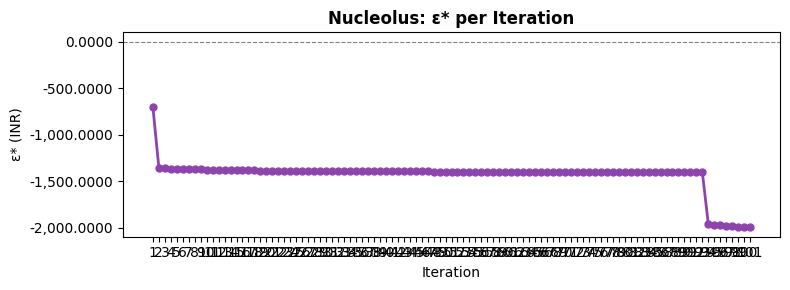

Figure 4 saved.


In [30]:
# Plot 4: Nucleolus ε convergence trace
if nuc_result["n_iterations"] > 1:
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(range(1, nuc_result["n_iterations"] + 1),
            nuc_result["epsilon_sequence"],
            "o-", color="#8e44ad", linewidth=2, markersize=5)
    ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
    ax.set_title("Nucleolus: ε* per Iteration", fontweight="bold")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("ε* (INR)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.4f}"))
    ax.set_xticks(range(1, nuc_result["n_iterations"] + 1))
    plt.tight_layout()
    plt.savefig(f"{config.PROCESSED_DIR}/nb04_nucleolus_convergence.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print("Figure 4 saved.")

## 11. Summary scorecard

In [31]:
scorecard_rows = []
for name in ["Least Core", "Nucleolus", "Shapley", "Equal Split", "Proportional"]:
    alloc = mechanisms[name]
    vr    = verification_results.get(name, {})
    if alloc is None:
        continue

    a_sorted = np.sort(alloc)
    n_       = len(a_sorted)
    gini = (
        2 * np.sum(np.arange(1, n_+1) * a_sorted) / (n_ * a_sorted.sum()) - (n_+1)/n_
        if a_sorted.sum() > 0 else 0.0
    )

    gain       = alloc - sv_vec
    min_gain   = gain.min()
    min_farmer = farmer_ids[gain.argmin()]

    ct         = carbon_transfers(alloc)
    min_ct     = ct.min()
    min_ct_fid = farmer_ids[ct.argmin()]

    scorecard_rows.append({
        "Mechanism"       : name,
        "Efficient"       : "Yes" if vr.get("efficiency_ok") else "No",
        "IR_satisfied"    : "Yes" if vr.get("IR_ok")         else "No",
        "Core_satisfied"  : "Yes" if vr.get("core_ok")       else "No",
        "Core_violations" : vr.get("n_core_violations", "N/A"),
        "Max_excess_INR"  : round(vr.get("max_excess", float("nan")), 2),
        "Gini_coeff"      : round(gini, 4),
        "Min_gain_x_INR"  : round(min_gain, 0),
        "Min_gain_farmer" : min_farmer,
        "Min_CT_INR"      : round(min_ct, 0),
        "Min_CT_farmer"   : min_ct_fid,
    })

df_scorecard = pd.DataFrame(scorecard_rows)
display(df_scorecard)
print()
print("Min_gain_x   : min(x_i - standalone_i)  — game-theoretic protection")
print("Min_CT       : min carbon transfer       — smallest actual cash payment")
print("Negative CT  : manager recovers money from farmer (rare but possible when")
print("               yield gain is very large and overshoots the entitlement)")

,Mechanism,Efficient,IR_satisfied,Core_satisfied,Core_violations,Max_excess_INR,Gini_coeff,Min_gain_x_INR,Min_gain_farmer,Min_CT_INR,Min_CT_farmer
0,Least Core,Yes,Yes,Yes,0,0,0,"23,482",F0002,"4,053",F0002
1,Nucleolus,Yes,Yes,Yes,0,-703,0,"22,831",F0002,"3,401",F0002
2,Shapley,Yes,Yes,No,9734,"50,499",0,"15,391",F0002,"-4,038",F0002
3,Equal Split,Yes,Yes,No,15237,"354,040",0,"99,961",F0001,"-73,053",F0012
4,Proportional,Yes,Yes,No,21,504,0,"23,746",F0002,"4,317",F0002



Min_gain_x   : min(x_i - standalone_i)  — game-theoretic protection
Min_CT       : min carbon transfer       — smallest actual cash payment
Negative CT  : manager recovers money from farmer (rare but possible when
               yield gain is very large and overshoots the entitlement)


## 12. Save allocation results

In [32]:
output = {
    "farmer_ids"        : farmer_ids,
    "standalone_values" : sv_vec,
    "v_grand"           : v_gc,
    "carbon_pool"       : carbon_pool,
    "yr_gc_vec"         : yr_gc_vec,
    "oc_gc_vec"         : oc_gc_vec,
    "allocations": {
        "least_core"   : lc_result["allocation"],
        "nucleolus"    : nuc_result["allocation"],
        "shapley"      : shapley_alloc,
        "equal_split"  : equal_alloc,
        "proportional" : prop_alloc,
    },
    "carbon_transfers": {
        "least_core"   : carbon_transfers(lc_result["allocation"]),
        "nucleolus"    : carbon_transfers(nuc_result["allocation"]),
        "shapley"      : carbon_transfers(shapley_alloc),
        "equal_split"  : carbon_transfers(equal_alloc),
        "proportional" : carbon_transfers(prop_alloc),
    },
    "least_core_meta": {
        "core_nonempty": lc_result["core_nonempty"],
        "epsilon_star" : lc_result["epsilon_star"],
        "stable"       : lc_result["stable"],
    },
    "nucleolus_meta": {
        "n_iterations"    : nuc_result["n_iterations"],
        "epsilon_sequence": nuc_result["epsilon_sequence"],
    },
    "verification"  : verification_results,
    "scorecard_df"  : df_scorecard,
    "allocation_df" : df_alloc,
}

out_path = Path(config.PROCESSED_DIR) / "allocation_results.pkl"
with open(out_path, "wb") as f:
    pickle.dump(output, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Saved: {out_path.resolve()}")
print()
print("=" * 60)
print("NOTEBOOK 04 COMPLETE")
print("=" * 60)
print(f"  Grand coalition value   : {v_gc:,.0f} INR")
print(f"  Carbon pool             : {carbon_pool:,.0f} INR")
print(f"  Core non-empty          : {lc_result['core_nonempty']}")
print(f"  Least-core ε*           : {lc_result['epsilon_star']:,.4f} INR")
print(f"  Nucleolus iterations    : {nuc_result['n_iterations']}")
print(f"  Output                  : {out_path}")

Saved: /Users/rohitsuresh/Desktop/CGT_Carbon_farming/data/processed/Experiment_01_Baseline/allocation_results.pkl

NOTEBOOK 04 COMPLETE
  Grand coalition value   : 1,499,422 INR
  Carbon pool             : 272,591 INR
  Core non-empty          : True
  Least-core ε*           : 0.0000 INR
  Nucleolus iterations    : 101
  Output                  : /Users/rohitsuresh/Desktop/CGT_Carbon_farming/data/processed/Experiment_01_Baseline/allocation_results.pkl
